# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Annie Nguyen

**Date:** 9/10/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


# Question 2.1 & 2.2
Through the histogram of the Foreign Gift Amount data, it can be said that majority of gifts are small and very few are large. 

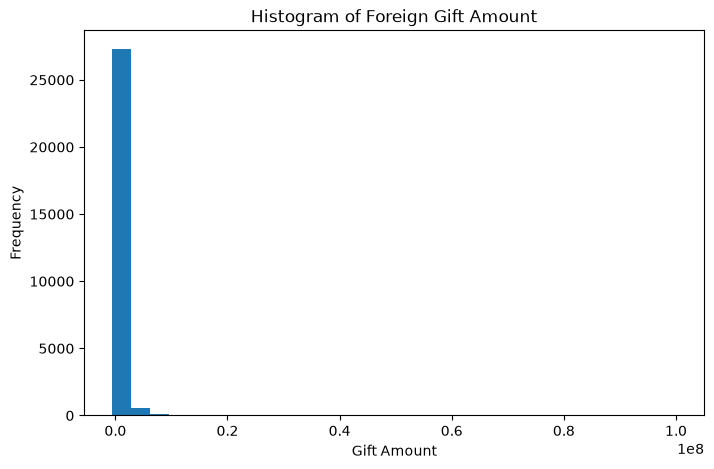

In [ ]:
# Question 2.2 Solution

# load the dataset (2.1)
import pandas as pd
import matplotlib.pyplot as plt

df2_2 = pd.read_csv('data/ForeignGifts_edu.csv')

# checking dataset structure
# df2_2.head()
# df2_2.info()
# df2_2.columns

# making sure columns are numeric
df2_2["Foreign Gift Amount"] = pd.to_numeric(df2_2["Foreign Gift Amount"], errors="coerce")

# making histogram (2.2)
df2_2["Foreign Gift Amount"].plot.hist(bins=30, figsize=(8,5))
plt.title("Histogram of Foreign Gift Amount")
plt.xlabel("Gift Amount")
plt.ylabel("Frequency")
plt.show()

# Question 2.3 
The majority of gifts are of type Contract. Monetary gifts were the second-largest type, while real estate gifts, compared to Monetary and Contract, are rare. 

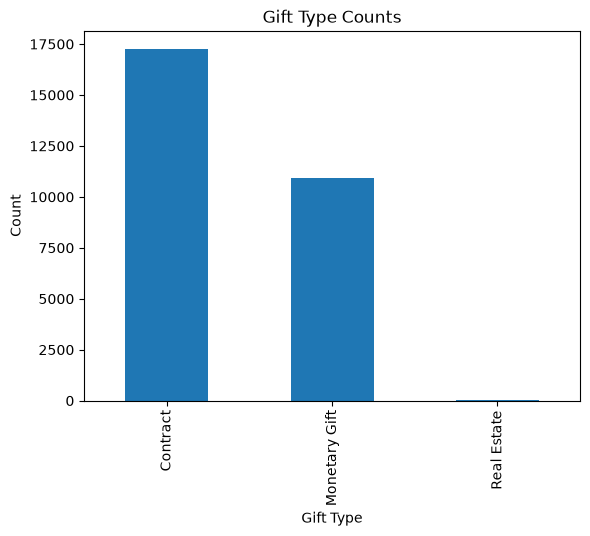

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


In [17]:
# Question 2.3 Solution

# load the dataset
import pandas as pd
import matplotlib.pyplot as plt

df2_3 = pd.read_csv('data/ForeignGifts_edu.csv')

# making histogram (2.3)
df2_3["Gift Type"].value_counts().plot(kind="bar")
plt.title("Gift Type Counts")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.show()

# finding proportions
print(df2_3["Gift Type"].value_counts(normalize=True))

# Question 2.4 
I found that after taking the log of the gift amount it was much easier to compare. The pattern I saw was that the gift type curves do not overlap, meaning they had different gift sizes across all categories. Some gifts types have a larger average, while the others are more concentrated at lower averages. 

c:\Users\annie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\annie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


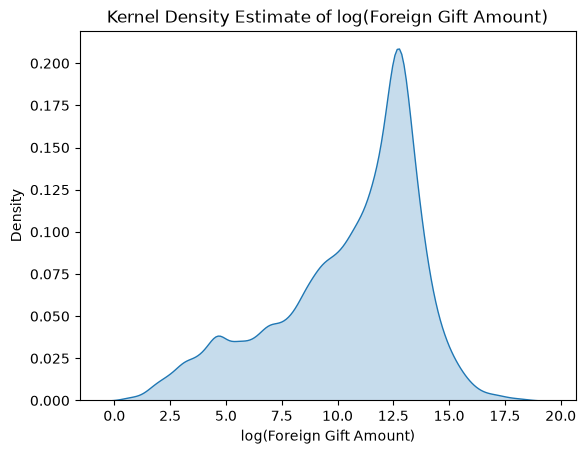

c:\Users\annie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\annie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


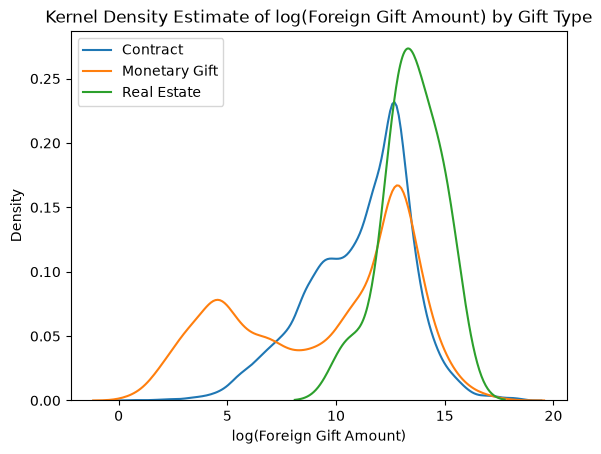

In [ ]:
# Question 2.4 Solution
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df2_4 = pd.read_csv("data/ForeignGifts_edu.csv")

# convert gift amount to numeric
df2_4["Foreign Gift Amount"] = pd.to_numeric(df2_4["Foreign Gift Amount"], errors="coerce")

# log transform for the amount variable
df2_4["log_amount"] = np.log1p(df2_4["Foreign Gift Amount"])

sns.kdeplot(df2_4["log_amount"].dropna(), fill=True)
plt.title("Kernel Density Estimate of log(Foreign Gift Amount)")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

df_KDE = df2_4.dropna(subset=["Gift Type", "Foreign Gift Amount"]).copy()
df_KDE["log_amount"] = np.log1p(df_KDE["Foreign Gift Amount"])

for gift_type, group in df_KDE.groupby("Gift Type"):
    sns.kdeplot(group["log_amount"], label=gift_type)

plt.title("Kernel Density Estimate of log(Foreign Gift Amount) by Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Question 2.5
The top 15 countries in terms of the number of gifts was: England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, Taiwan. 
The top 15 countries in terms of the total amount given was: Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, United Arab Emirates, France, Singapore, Australia

In [22]:
# Question 2.5 Solution
import pandas as pd
import numpy as np

df2_5 = pd.read_csv("data/ForeignGifts_edu.csv")

# make sure amount is numeric
df2_5["Foreign Gift Amount"] = pd.to_numeric(df2_5["Foreign Gift Amount"], errors="coerce")

country_total = df2_5.groupby("Country of Giftor").size().sort_values(ascending=False)
print("By number of gifts:")
print(country_total.head(15))

country_total_gift_amount = df2_5.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)
print("By total amount:")
print(country_total_gift_amount.head(15))

By number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
By total amount:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dt

# Question 2.6 
The Gifter that provided the most money in total was Qatar Foundation. 

In [ ]:
import pandas as pd

df2_6 = pd.read_csv("data/ForeignGifts_edu.csv")
df2_6["Foreign Gift Amount"] = pd.to_numeric(df2_6["Foreign Gift Amount"], errors="coerce")

donor_total = df2_6.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)
print(donor_total.head(10))

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Name: Foreign Gift Amount, dtype: int64


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID: a8f96b59e82f23f3fa86bf4e84ed4043577f80f1
- **AI tool and model used:** ChatGPT

### *Prompts used

1. Can you check my proofs for the file Question_1_2.JPG?
2. Can you check my proofs for the file Question_3_4.JPG?
3. Do I need to do more cleaning for all parts of question 2?

### *AI-proposed changes


The AI suggestions were evaluated as follows:

1. The proofs are mathematically correct. The first proof shows that the mean is linear:

   $$
   m(a+bX)=a+b\,m(X).
   $$

   The second proof shows that adding a constant does not change covariance, while multiplying a variable by $b$ scales covariance by $b$:

   $$
   \operatorname{cov}(X,a+bY)=b\,\operatorname{cov}(X,Y).
   $$

   For clarity, use consistent random-variable notation, such as $X$ and $Y$, and write $m(X)$ or $E[X]$ consistently throughout.

2. The proof correctly shows that variance under a linear transformation is scaled by $b^2$:

   $$
   \begin{aligned}
   \operatorname{var}(a+bX)
   &=\frac{1}{N}\sum_{i=1}^{N}\left[(a+bx_i)-(a+b\,m(X))\right]^2 \\
   &=\frac{1}{N}\sum_{i=1}^{N}\left[b(x_i-m(X))\right]^2 \\
   &=b^2\operatorname{var}(X).
   \end{aligned}
   $$

   The conclusion about a non-decreasing transformation is also correct: it preserves the ordering of values, but it does not generally preserve the mean. Use consistent notation such as $m(X)$ instead of switching between $m(x)$ and $m(X).
3. ## Recommended Cleaning for Question 2

**Question 2.2**
   - State that the distribution is strongly right-skewed.
   - Mention that most gifts are small, with a few very large outliers.
   - Use `dropna()` before plotting and label the x-axis as dollars.

**Question 2.3**
   - Include the actual proportions, not only which category is largest.
   - Format the proportions as percentages.
   - Make sure the written answer matches the printed table exactly.

**Question 2.4**
   - Explain that `np.log1p()` was used so zero-dollar values could be included.
   - Avoid saying that the curves “do not overlap” unless this is clearly visible.
   - Instead, state that the gift types have different distributions or centers.

**Question 2.5**
   - Include the counts and dollar totals alongside the country names.
   - Remove the unused `numpy` import.
   - Keep country names exactly as they appear in the dataset.

**Question 2.6**
   - Include the total amount given by the top giftor, not just the name.
   - Clarify that the result comes from sorting total gift amounts in descending order.



### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I did not modify anything, but accepted that the ChatGPT said my answers were correct. |
| 2 | Accept | I did not modify anything, but accepted that the ChatGPT said my answers were correct. |
| 3 | Accept/Modify  | I added changes to make sure my results showed the most accurate values.  |

### *AI-assisted solution in full: more cleaning

The following cells contain the cleaned Phase 2 version of Question 2. Phase 1 remains unchanged.

# Question 2.1 & 2.2

Through the histogram of the Foreign Gift Amount data, it can be said that majority of gifts are small and very few are large.

In [ ]:
# Question 2.2 Solution
# More cleaning: convert the gift amounts to numeric values, remove missing amounts
# before plotting, describe the right-skewed distribution, and label the x-axis in dollars.

import pandas as pd
import matplotlib.pyplot as plt

df2_2 = pd.read_csv("data/ForeignGifts_edu.csv")
df2_2["Foreign Gift Amount"] = pd.to_numeric(
    df2_2["Foreign Gift Amount"], errors="coerce"
)

amounts = df2_2["Foreign Gift Amount"].dropna()
amounts.plot.hist(bins=30, figsize=(8, 5), edgecolor="black")
plt.title("Distribution of Foreign Gift Amount")
plt.xlabel("Foreign Gift Amount (dollars)")
plt.ylabel("Number of Gifts")
plt.tight_layout()
plt.show()

print("Most gifts are relatively small, while a small number are much larger.")
print("The distribution is strongly right-skewed and contains large high-value observations.")

# Question 2.3

The majority of gifts are of type Contract. Monetary gifts were the second-largest type, while real estate gifts, compared to Monetary and Contract, are rare.

In [ ]:
# Question 2.3 Solution
# More cleaning: remove missing gift types, print exact counts and percentages,
# and use clear labels for the gift-type chart.

import pandas as pd
import matplotlib.pyplot as plt

df2_3 = pd.read_csv("data/ForeignGifts_edu.csv")
gift_types = df2_3["Gift Type"].dropna()
gift_type_counts = gift_types.value_counts()
gift_type_percentages = gift_types.value_counts(normalize=True).mul(100).round(2)

gift_type_counts.plot(kind="bar", figsize=(8, 5), edgecolor="black")
plt.title("Number of Gifts by Gift Type")
plt.xlabel("Gift Type")
plt.ylabel("Number of Gifts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Gift type counts:")
print(gift_type_counts)
print("\nGift type percentages:")
print(gift_type_percentages.astype(str) + "%")

# Question 2.4

I found that after taking the log of the gift amount it was much easier to compare. The pattern I saw was that the gift type curves do not overlap, meaning they had different gift sizes across all categories. Some gifts types have a larger average, while the others are more concentrated at lower averages.

In [ ]:
# Question 2.4 Solution
# More cleaning: convert amounts to numeric, keep non-negative values for log1p,
# remove missing gift types from the conditional plot, and use clearer plot labels.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df2_4 = pd.read_csv("data/ForeignGifts_edu.csv")
df2_4["Foreign Gift Amount"] = pd.to_numeric(
    df2_4["Foreign Gift Amount"], errors="coerce"
)

# Keep non-negative amounts so log1p receives valid values.
df2_4 = df2_4[df2_4["Foreign Gift Amount"] >= 0].copy()
df2_4["log_amount"] = np.log1p(df2_4["Foreign Gift Amount"])

sns.kdeplot(data=df2_4, x="log_amount", fill=True)
plt.title("Density of log(1 + Foreign Gift Amount)")
plt.xlabel("log(1 + Foreign Gift Amount)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

sns.kdeplot(
    data=df2_4.dropna(subset=["Gift Type"]),
    x="log_amount",
    hue="Gift Type",
    common_norm=False,
)
plt.title("Density of log(1 + Foreign Gift Amount) by Gift Type")
plt.xlabel("log(1 + Foreign Gift Amount)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Question 2.5

The top 15 countries in terms of the number of gifts was: England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, Taiwan.

The top 15 countries in terms of the total amount given was: Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, United Arab Emirates, France, Singapore, Australia

In [ ]:
# Question 2.5 Solution
# More cleaning: remove missing country or amount values, sort each ranking,
# and print the country amounts with dollar formatting.

import pandas as pd

df2_5 = pd.read_csv("data/ForeignGifts_edu.csv")
df2_5["Foreign Gift Amount"] = pd.to_numeric(
    df2_5["Foreign Gift Amount"], errors="coerce"
)

country_counts = (
    df2_5.dropna(subset=["Country of Giftor"])
    .groupby("Country of Giftor")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

country_amounts = (
    df2_5.dropna(subset=["Country of Giftor", "Foreign Gift Amount"])
    .groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 countries by number of gifts:")
print(country_counts)
print("\nTop 15 countries by total amount given:")
print(country_amounts.map(lambda amount: f"${amount:,.2f}"))

# Question 2.6

The Gifter that provided the most money in total was Qatar Foundation.

In [ ]:
# Question 2.6 Solution
# More cleaning: remove missing giftor or amount values, rank giftors by total,
# and print the top giftor together with the total amount provided.

import pandas as pd

df2_6 = pd.read_csv("data/ForeignGifts_edu.csv")
df2_6["Foreign Gift Amount"] = pd.to_numeric(
    df2_6["Foreign Gift Amount"], errors="coerce"
)

giftor_amounts = (
    df2_6.dropna(subset=["Giftor Name", "Foreign Gift Amount"])
    .groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Giftors ranked by total amount given:")
print(giftor_amounts.head(10).map(lambda amount: f"${amount:,.2f}"))
print(
    f"The giftor providing the most money is {giftor_amounts.index[0]}, "
    f"with a total of ${giftor_amounts.iloc[0]:,.2f}."
)

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements was improving my methods of cleaning data and validating my proofs. I believe these improvements, with the help of AI, increased my confidence in my answers, especially for the proofs. Furthermore, in this phase I was able to correct my cleaning of data, since I did not do enough in Phase 1, which will improve my data, values, and computations. Though AI was very helpful in checking and proving my work, it doesn't heavily improve or increase my understanding of the topics, so in-order to verify my solutions were correct I had to confirm my own understandings.